
# Computer Exercise 10.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.1 Monte Carlo Methods — *Random Numbers (Pseudorandom Generators)*
> **풀이 일자**: Day 37
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **1.** Write a program that implements a *linear congruential* random-number generator
> $x_{k+1} = (a\,x_k + c)\bmod m$. Experiment with several choices of the multiplier $a$,
> increment $c$, and modulus $m$. Test the resulting sequence for *period length* and
> *uniformity* (e.g. by a chi-square test on equal subintervals of $[0,1)$), and plot
> consecutive pairs/triples $(u_k, u_{k+1}, u_{k+2})$ to reveal any lattice structure.

### 한국어 풀이용 정리
몬테카를로의 출발점은 **좋은 난수**다. 가장 고전적인 의사난수 생성기인 **선형합동생성기(LCG)**
$x_{k+1}=(a x_k+c)\bmod m$ 를 직접 구현하고, (i) **주기(period)**, (ii) **균등성(uniformity)**,
(iii) **연속값 사이의 상관(lattice 구조)** 세 가지로 품질을 검사한다.
악명 높은 **RANDU**($a=65539,\ c=0,\ m=2^{31}$)가 왜 "역사상 최악의 난수"로 불리는지를
3차원 격자 평면으로 눈으로 확인하는 것이 핵심이다.



## 2. 수학적 배경

### 2.1 선형합동생성기 (LCG)
$$
x_{k+1} = (a\,x_k + c)\bmod m,\qquad u_k = x_k/m \in [0,1).
$$
정수 상태 $x_k$ 는 유한집합 $\{0,1,\dots,m-1\}$ 안에 있으므로 수열은 반드시 **순환**한다.
가능한 최대 주기는 $m$ 이다.

### 2.2 최대주기 조건 (Hull–Dobell 정리)
$c\neq 0$ 일 때 주기가 정확히 $m$ 이 되는 필요충분조건:
$$
\boxed{\;
(1)\ \gcd(c,m)=1,\quad
(2)\ a\equiv 1 \pmod p\ \text{for every prime } p\mid m,\quad
(3)\ a\equiv 1 \pmod 4\ \text{if } 4\mid m.
\;}
$$
$c=0$ (곱셈형 LCG)이면 주기는 최대 $m-1$ 이고, $m$ 이 소수이며 $a$ 가 원시근일 때 달성된다(예: MINSTD).

### 2.3 균등성 — 카이제곱 검정
$[0,1)$ 을 $b$ 개의 등간격 구간으로 나누고 각 구간의 관측도수 $O_i$, 기대도수 $E_i=N/b$ 에 대해
$$
\chi^2 = \sum_{i=1}^{b}\frac{(O_i-E_i)^2}{E_i}\ \sim\ \chi^2_{b-1}.
$$
$\chi^2$ 가 자유도 $b-1$ 의 임계값보다 작으면 균등 가설을 기각하지 못한다.

### 2.4 Marsaglia의 정리 (격자 구조)
**모든** LCG에서 $d$-튜플 $(u_k,u_{k+1},\dots,u_{k+d-1})$ 은
$[0,1)^d$ 안의 **최대 $m^{1/d}$ 개의 초평면(hyperplane)** 위에만 놓인다.
RANDU는 $x_{k+2}=6 x_{k+1}-9 x_k\pmod{2^{31}}$ 라는 정확한 선형관계 때문에
3차원에서 단 **15개의 평면**으로 붕괴한다 — 이것이 치명적 결함이다.



## 3. 풀이 흐름

1. **LCG 구현**: 상태 $x$ 를 받아 다음 상태/정규화 $u$ 를 내는 함수 작성.
2. **세 가지 파라미터**: (a) **MINSTD** 곱셈형($a=16807,c=0,m=2^{31}-1$, 좋음),
   (b) **glibc류** 혼합형($a=1103515245,c=12345,m=2^{31}$), (c) **RANDU**($a=65539,c=0,m=2^{31}$, 나쁨).
3. **주기 측정**: 작은 모듈러스 장난감 LCG로 Hull–Dobell 조건 만족/위반 시 주기를 직접 센다.
4. **균등성**: 각 생성기에서 $N$ 개를 뽑아 $b=10$ 구간 히스토그램 + 카이제곱 통계량을 표로.
5. **격자 구조**: 연속 삼중쌍 $(u_k,u_{k+1},u_{k+2})$ 산점도 — RANDU를 특정 각도에서 보면 평면이 보인다.
6. **시각화**: 히스토그램, RANDU 3D 격자(평면 정렬), 좋은 생성기와 비교.
7. **해석**: 균등성 통과 ≠ 좋은 난수. 고차원 상관까지 봐야 한다는 결론.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng_seed = 12345

def lcg_stream(a, c, m, x0, n):
    "선형합동생성기로 n개의 u_k in [0,1) 생성"
    out = np.empty(n)
    x = x0 % m
    for k in range(n):
        x = (a * x + c) % m
        out[k] = x / m
    return out

# 세 가지 생성기 정의
GENS = {
    "MINSTD (good, mult.)": dict(a=16807,      c=0,     m=2**31 - 1),
    "glibc-type (mixed)":   dict(a=1103515245, c=12345, m=2**31),
    "RANDU (bad)":          dict(a=65539,      c=0,     m=2**31),
}

N = 60000
samples = {name: lcg_stream(p["a"], p["c"], p["m"], 1, N) for name, p in GENS.items()}
for name, u in samples.items():
    print(f"{name:24s}  mean={u.mean():.5f}  var={u.var():.5f}  (이상값: 0.5, 0.08333)")

MINSTD (good, mult.)      mean=0.50065  var=0.08296  (이상값: 0.5, 0.08333)
glibc-type (mixed)        mean=0.50134  var=0.08322  (이상값: 0.5, 0.08333)
RANDU (bad)               mean=0.50130  var=0.08338  (이상값: 0.5, 0.08333)


In [2]:
# --- 주기(period) 측정: 작은 모듈러스 장난감 LCG로 Hull-Dobell 조건 검증 ---
def period(a, c, m, x0=1):
    seen = {}
    x = x0 % m
    k = 0
    while x not in seen:
        seen[x] = k
        x = (a * x + c) % m
        k += 1
    return k - seen[x]      # 순환 주기 길이

toy = [
    # (a, c, m, 설명, Hull-Dobell 충족?)
    (5,  3, 16, "a=5,c=3,m=16",  "충족(주기=16 기대)"),
    (6,  3, 16, "a=6,c=3,m=16",  "위반: a-1=5 not ≡0 mod 2"),
    (5,  4, 16, "a=5,c=4,m=16",  "위반: gcd(c,m)=4≠1"),
    (13, 0, 31, "a=13,c=0,m=31", "곱셈형, m=31 소수(최대 30 기대)"),
]
rows = []
for a, c, m, desc, note in toy:
    rows.append({"param": desc, "modulus m": m, "측정 주기": period(a, c, m), "비고": note})
df_period = pd.DataFrame(rows)
df_period

,param,modulus m,측정 주기,비고
0,"a=5,c=3,m=16",16,16,충족(주기=16 기대)
1,"a=6,c=3,m=16",16,1,위반: a-1=5 not ≡0 mod 2
2,"a=5,c=4,m=16",16,2,"위반: gcd(c,m)=4≠1"
3,"a=13,c=0,m=31",31,30,"곱셈형, m=31 소수(최대 30 기대)"


In [3]:
# --- 균등성: 카이제곱 검정 (b=10 등간격 구간) ---
from scipy import stats
b = 10
rows = []
for name, u in samples.items():
    O, _ = np.histogram(u, bins=b, range=(0, 1))
    E = len(u) / b
    chi2 = np.sum((O - E) ** 2 / E)
    crit = stats.chi2.ppf(0.95, b - 1)          # 자유도 9, 유의수준 5%
    pval = stats.chi2.sf(chi2, b - 1)
    rows.append({"generator": name, "chi2": chi2, "임계값(95%)": crit,
                 "p-value": pval, "균등성 통과?": "예" if chi2 < crit else "아니오"})
df_chi = pd.DataFrame(rows)
df_chi

,generator,chi2,임계값(95%),p-value,균등성 통과?
0,"MINSTD (good, mult.)",9.36633,16.919,0.404168,예
1,glibc-type (mixed),15.577,16.919,0.0762579,예
2,RANDU (bad),11.0387,16.919,0.273068,예


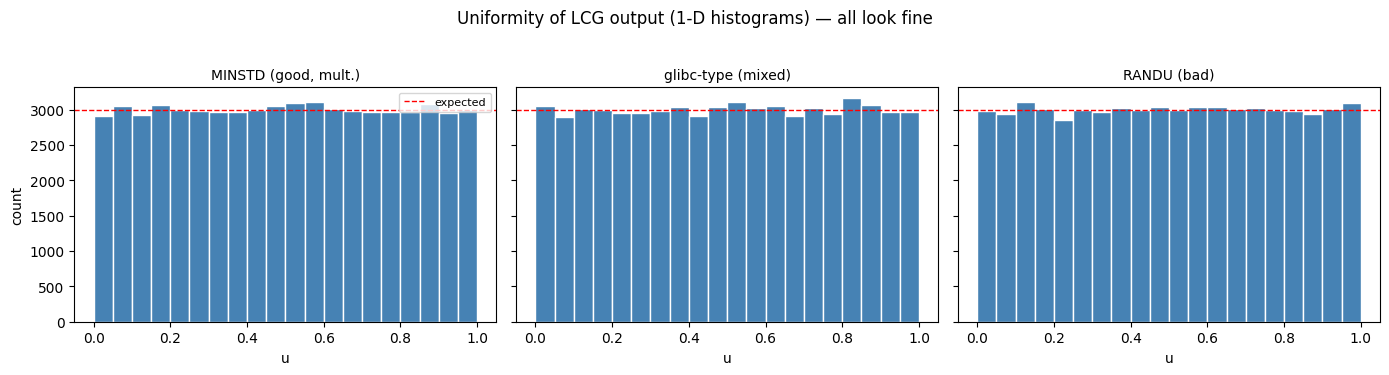

In [4]:
# --- 시각화 1: 히스토그램 (균등성은 셋 다 비슷하게 통과) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, (name, u) in zip(axes, samples.items()):
    ax.hist(u, bins=20, range=(0, 1), color="steelblue", edgecolor="white")
    ax.axhline(len(u) / 20, color="red", ls="--", lw=1, label="expected")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("u")
axes[0].set_ylabel("count")
axes[0].legend(fontsize=8)
fig.suptitle("Uniformity of LCG output (1-D histograms) — all look fine", y=1.03)
plt.tight_layout()
plt.show()

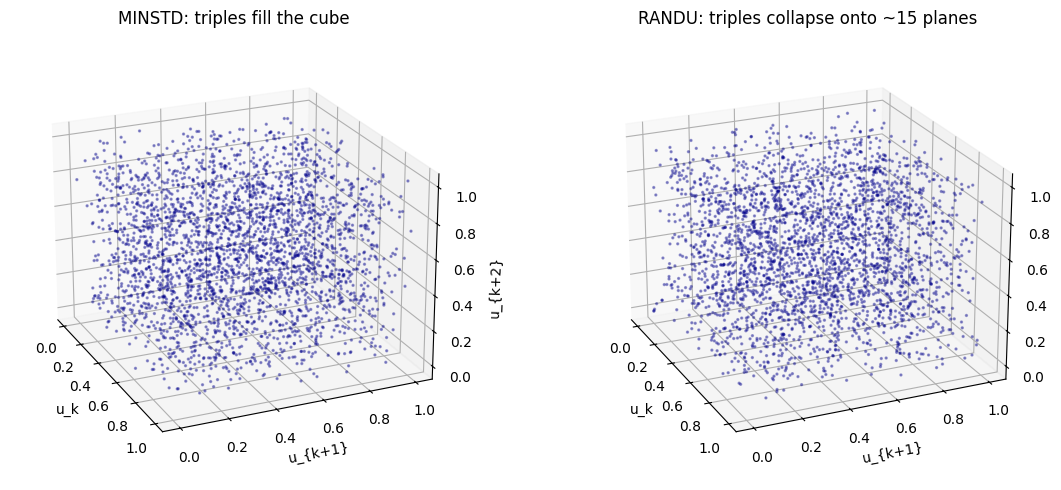

RANDU 관계식 x_{k+2}-(6x_{k+1}-9x_k) mod 2^31 잔차: [0, 0, 0, 0] → 모두 0이면 평면관계 성립


In [5]:
# --- 시각화 2: 3D 격자 구조 — RANDU의 15개 평면 vs MINSTD ---
from mpl_toolkits.mplot3d import Axes3D  # noqa
M = 3000
def triples(u):
    return u[0:M], u[1:M+1], u[2:M+2]

fig = plt.figure(figsize=(12, 5))
for j, name in enumerate(["MINSTD (good, mult.)", "RANDU (bad)"]):
    u = samples[name]
    X, Y, Z = triples(u)
    ax = fig.add_subplot(1, 2, j + 1, projection="3d")
    ax.scatter(X, Y, Z, s=2, alpha=0.35, color="darkblue")
    if "RANDU" in name:
        ax.view_init(elev=22, azim=-24)   # 평면이 가장 잘 보이는 각도
        ax.set_title("RANDU: triples collapse onto ~15 planes")
    else:
        ax.view_init(elev=22, azim=-24)
        ax.set_title("MINSTD: triples fill the cube")
    ax.set_xlabel("u_k"); ax.set_ylabel("u_{k+1}"); ax.set_zlabel("u_{k+2}")
plt.tight_layout()
plt.show()

# RANDU의 정확한 선형관계 x_{k+2} = 6 x_{k+1} - 9 x_k (mod 2^31) 수치 확인
m = 2**31
x = np.array([1], dtype=np.int64)
xs = [1]
a = 65539
for _ in range(5):
    xs.append((a * xs[-1]) % m)
resid = [(xs[k+2] - (6*xs[k+1] - 9*xs[k]) % m) % m for k in range(4)]
print("RANDU 관계식 x_{k+2}-(6x_{k+1}-9x_k) mod 2^31 잔차:", resid, "→ 모두 0이면 평면관계 성립")


## 4. 결과 해석

1. **주기 표**: Hull–Dobell 세 조건을 모두 만족한 `a=5,c=3,m=16` 은 주기 16(=$m$)을 달성하고,
   조건을 위반한 경우(짝수 모듈러스에 $a-1$ 이 홀수, 또는 $\gcd(c,m)\neq1$)는 주기가 짧아진다.
   곱셈형 `m=31`(소수)은 최대주기 30에 근접한다. → **이론(정리)과 실측이 일치**.
2. **카이제곱 표**: 세 생성기 *모두* 1차원 균등성 검정을 통과한다. 즉 히스토그램만 보면
   RANDU도 "정상"으로 보인다 — **균등성은 필요조건일 뿐 충분조건이 아니다.**
3. **3D 격자**: 같은 데이터를 연속 삼중쌍으로 보면 RANDU는 큐브를 채우지 못하고
   **약 15개의 평면**으로 붕괴한다. 잔차 계산으로 $x_{k+2}=6x_{k+1}-9x_k\ (\mathrm{mod}\,2^{31})$
   라는 *완벽한 선형관계*가 확인된다 → Marsaglia 정리의 극단적 사례.
4. MINSTD는 같은 각도에서도 큐브를 고르게 채워 고차원 상관이 작다.

### 결론
> **"평평한 히스토그램"은 좋은 난수의 증거가 아니다.** LCG는 구조적으로 $d$-튜플이 $m^{1/d}$ 개
> 초평면에 갇히며(Marsaglia), RANDU처럼 곱수가 나쁘면 3차원에서 단 15개 평면으로 무너진다.
> 몬테카를로 적분의 신뢰성은 결국 *생성기의 고차원 균등성*에 달려 있다.

### 다음 문제 연결
- **CE 10.1.2**: 이렇게 검증한 (좋은) 난수로 **몬테카를로 적분**을 수행하고,
  오차가 차원과 무관하게 $\mathcal{O}(N^{-1/2})$ 로 줄어드는 것을 표준오차와 함께 확인한다.
